## Search by Text

LGND's `search-by-text` endpoint converts a natural-language query into an embedding and returns the most visually similar chips in the collection ranked by cosine similarity. Results are plotted as orange polygons on an interactive satellite basemap centered on California.

In [ ]:
import os
import requests
import folium
from dotenv import load_dotenv

load_dotenv()  # reads .env locally; on Colab, set these via Secrets (the key icon in the sidebar)

API_KEY       = os.environ["LGND_API_KEY"]
TENANT_ID     = os.environ["LGND_TENANT_ID"]
COLLECTION_ID = os.environ["LGND_COLLECTION_ID"]
BASE_URL      = "https://embeddings.api.lgnd.ai/v1"

headers = {"Authorization": f"Bearer {API_KEY}", "Content-Type": "application/json"}
# LGND's search-by-text endpoint embeds the query string and finds the most visually
# similar satellite image chips in the collection using cosine similarity.
response = requests.post(
    f"{BASE_URL}/tenants/{TENANT_ID}/collections/{COLLECTION_ID}/search-by-text",
    headers=headers,
    json={"query": "railyard", "top_k": 100}
)
response.raise_for_status()
search_results = response.json()
print(f"Found {len(search_results['data'])} results")

# Fetch California boundary for the map overlay
california_geojson = requests.get(
    "https://raw.githubusercontent.com/johan/world.geo.json/master/countries/USA/CA.geo.json"
).json()

# Each result includes a chip geometry — a small geographic tile of satellite imagery —
# along with a similarity score. We plot these as orange polygons on a satellite basemap.
m = folium.Map(location=[36.7783, -119.4179], zoom_start=8, tiles="Esri WorldImagery")

folium.GeoJson(california_geojson, name="California",
               style_function=lambda x: {"color": "black", "weight": 1}).add_to(m)

for result in search_results["data"]:
    if result.get("geometry", {}).get("type") == "Polygon":
        folium.GeoJson(
            result["geometry"],
            tooltip=f"Score: {result['score']:.2f}  |  {result.get('collection')}  |  {result.get('datetime', '')[:10]}",
            style_function=lambda x: {"fillColor": "#FFA500", "color": "orange", "weight": 2, "fillOpacity": 0.6},
        ).add_to(m)

folium.LayerControl().add_to(m)
display(m)

## Chip Thumbnails

Each chip exposes a `/thumbnail` endpoint that returns a JPEG preview of the satellite imagery at that location. This cell fetches and displays the top 3 results from the text search above.

Fetching thumbnails for 3 chips...



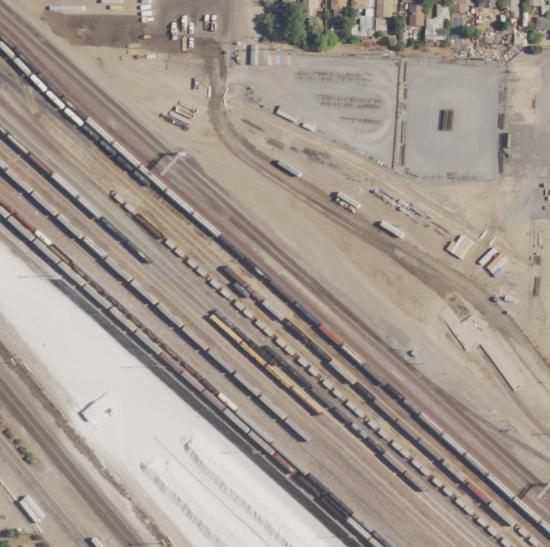

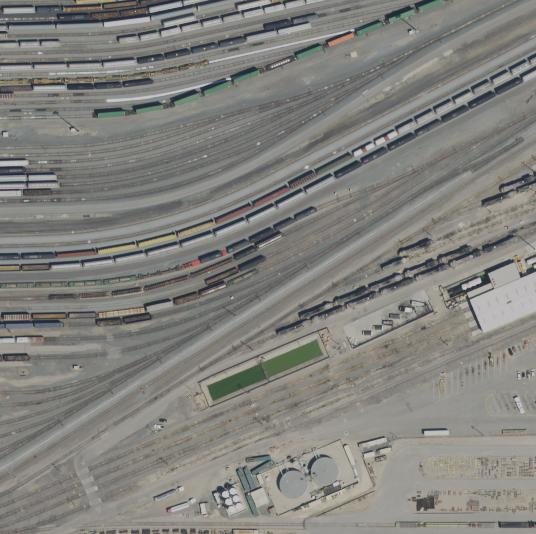

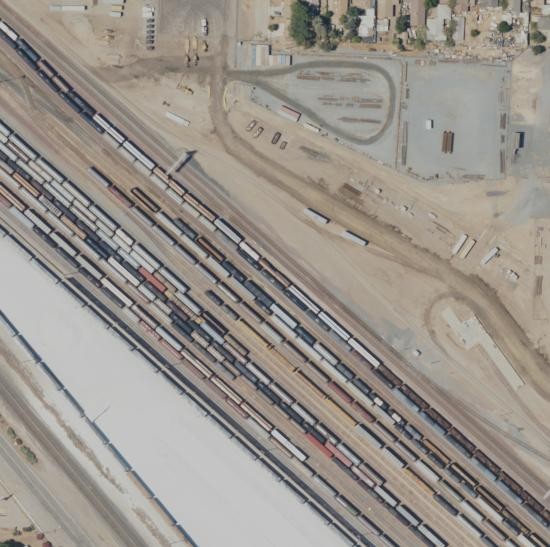

In [4]:
import requests
from IPython.display import display, Image
from math import ceil

CHIPS_BASE_URL = "https://embeddings.api.lgnd.ai/v1/chips"
MAX_THUMBNAILS = 3

chip_ids = [r['chip_id'] for r in search_results.get('data', [])][:MAX_THUMBNAILS]
print(f"Fetching thumbnails for {len(chip_ids)} chips...\n")

for chip_id in chip_ids:
    resp = requests.get(f"{CHIPS_BASE_URL}/{chip_id}/thumbnail", headers=headers)
    if resp.status_code == 200:
        display(Image(data=resp.content))
    else:
        print(f"Failed {chip_id}: {resp.status_code}")

## Chip Metadata

The `/chips/{chip_id}` endpoint returns structured metadata for a chip: collection name, capture date, geographic bounding box, and the path to the source raster asset. This is useful for understanding the imagery that underlies each search result.

In [16]:
for chip_id in chip_ids:
    resp = requests.get(f"{CHIPS_BASE_URL}/{chip_id}", headers=headers)
    if resp.status_code == 200:
        data = resp.json()
        print(f"=== {chip_id} ===")
        print(f"  Collection:      {data.get('collection')}")
        print(f"  Date:            {data.get('datetime')}")
        print(f"  Chip size (m):   {data.get('chip_size_m')}")
        print(f"  Raster ID:       {data.get('raster_id')}")
        print(f"  Factory version: {data.get('factory_version')}")
        geom = data.get('geometry', {})
        coords = geom.get('coordinates', [[]])[0]
        if coords:
            lons = [c[0] for c in coords]
            lats = [c[1] for c in coords]
            print(f"  Bounding box:    lon [{min(lons):.6f}, {max(lons):.6f}]  lat [{min(lats):.6f}, {max(lats):.6f}]")
    else:
        print(f"Failed {chip_id}: {resp.status_code}")

=== chip_985ab74af1bf4c5739a90a4676e1d319 ===
  Collection:      naip
  Date:            2020-06-17T00:00:00Z
  Chip size (m):   320
  Raster ID:       raster_0d5e52c8027893af446534bf2df8dfec
  Factory version: None
  Bounding box:    lon [-121.171037, -121.167358]  lat [38.608387, 38.611262]
=== chip_0a8db11e7f5602b568ddd875969be749 ===
  Collection:      naip
  Date:            2020-07-05T00:00:00Z
  Chip size (m):   320
  Raster ID:       raster_bc223c2a848d74d6b64d0a6b8e8e0100
  Factory version: None
  Bounding box:    lon [-119.800487, -119.796924]  lat [36.210994, 36.213868]
=== chip_471a415fbaa259598ad6681ef86ec6fd ===
  Collection:      naip
  Date:            2020-06-17T00:00:00Z
  Chip size (m):   320
  Raster ID:       raster_0d5e52c8027893af446534bf2df8dfec
  Factory version: None
  Bounding box:    lon [-121.164953, -121.161275]  lat [38.611262, 38.614137]


## Change Detection

LGND's `search-changed-chips` endpoint finds chips whose embeddings shifted in a direction you define — described here in plain text as land transitioning from cropland to solar panels. The API returns `changed_chip_pair` objects, each containing a `chip_past` and `chip_current` with their own chip IDs, scores, and geometries.

Found 3 changed chip pairs

  past:    chip_aefd5fe7d904d3326704792ce2de79b2  (score 0.4256)
  current: chip_80e22d1d2e062dfe15e3c807d674bb1c  (score 0.4203)

  past:    chip_774530ee39b312a868e8f3e636bc6572  (score 0.4118)
  current: chip_cbc20127f051568693d032ea3a71d919  (score 0.4311)

  past:    chip_2fd18d627128bdbb83c400c1c4428e99  (score 0.4012)
  current: chip_d55735867633da5414497e627a043a60  (score 0.4398)

Before


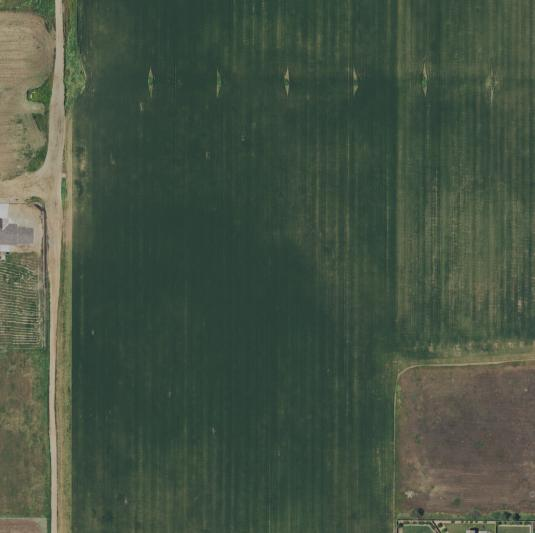

After


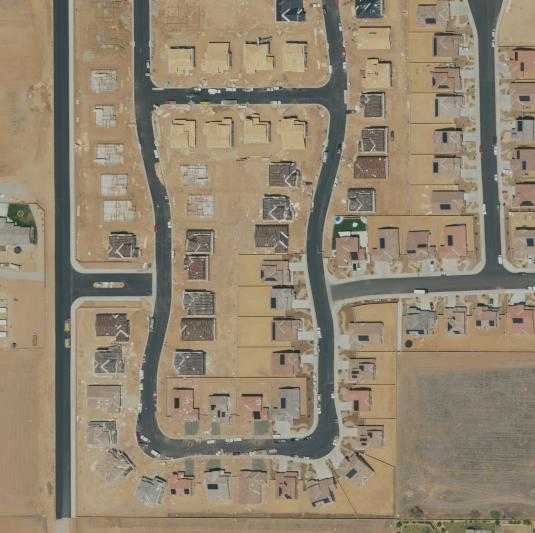

In [5]:
CHANGE_DETECTION_URL = f"{BASE_URL}/tenants/{TENANT_ID}/collections/{COLLECTION_ID}/search-changed-chips"

payload = {
    "positive_texts_past":    ["agricultural cropland fields"],
    "negative_texts_past":    ["homes"],
    "positive_texts_current": ["homes"],
    "negative_texts_current": ["agricultural cropland fields"],
    "top_k": 3,
}

resp = requests.post(CHANGE_DETECTION_URL, headers=headers, json=payload)
resp.raise_for_status()
changed_chips = resp.json()

# Each result is a changed_chip_pair with chip_past and chip_current
print(f"Found {len(changed_chips.get('data', []))} changed chip pairs\n")
for pair in changed_chips.get('data', []):
    print(f"  past:    {pair['chip_past']['chip_id']}  (score {pair['chip_past']['score']:.4f})")
    print(f"  current: {pair['chip_current']['chip_id']}  (score {pair['chip_current']['score']:.4f})")
    print()

# Display before/after thumbnails for the top-scoring pair
if changed_chips.get('data'):
    top = changed_chips['data'][0]
    for label, chip_id in [("Before", top['chip_past']['chip_id']), ("After", top['chip_current']['chip_id'])]:
        print(label)
        thumb_resp = requests.get(f"{CHIPS_BASE_URL}/{chip_id}/thumbnail", headers=headers)
        if thumb_resp.status_code == 200:
            display(Image(data=thumb_resp.content))